<div style="text-align: right; font-weight: bold;">
東京工科大学コンピュータサイエンス学部<br>
福西広晃
</div>

----

# 株価データを用いた売買タイミング分析の概要

- 株価データを用いた売買タイミング分析では、**過去の株価の動きから、買いや売りの判断に利用できるタイミングを探す**。

- 今回は、日経平均株価の終値を用いて、**移動平均線**を計算し、株価の短期的・中期的・長期的な傾向を確認する。

- 移動平均線とは、一定期間の株価の平均値を計算して線で表したものである。
  - **5日移動平均**：短期的な値動きを表す
  - **25日移動平均**：中期的な値動きを表す
  - **75日移動平均**：より長期的な値動きを表す

- 短期の移動平均線と中期の移動平均線の位置関係を見ることで、株価の流れが変化するタイミングを確認できる。

## ゴールデンクロス

- **ゴールデンクロス**とは、短期の移動平均線が中期の移動平均線を**下から上へ抜く**現象である。

- 今回は、**5日移動平均線が25日移動平均線を下から上へ抜いたポイント**をゴールデンクロスとして検出する。

- ゴールデンクロスは、株価が上昇傾向に変化する可能性を示すものとして、**買いタイミングを判断するための参考指標**として利用される。

## デッドクロス

- **デッドクロス**とは、短期の移動平均線が中期の移動平均線を**上から下へ抜く**現象である。

- 今回は、**5日移動平均線が25日移動平均線を上から下へ抜いたポイント**をデッドクロスとして検出する。

- デッドクロスは、株価が下降傾向に変化する可能性を示すものとして、**売りタイミングを判断するための参考指標**として利用される。

## 本演習で行う分析

1. 日経平均株価の終値を取得する
2. 株価の時系列グラフを作成する
3. 5日・25日・75日の移動平均を計算する
4. 株価と移動平均線を同じグラフに表示する
5. ゴールデンクロスを検出する
6. デッドクロスを検出する
7. クロスしたポイントをグラフ上に表示する
8. 売買タイミングとしてどのように利用できるかを考察する
9. 個別企業の株価で分析にチャレンジ

- ただし、ゴールデンクロスやデッドクロスが発生したからといって、必ずその後に株価が上昇・下降するとは限らない。

- そのため、実際の売買では、これらを**売買を決定する絶対的なルールではなく、判断材料の一つとして利用することが重要**である。

# データ取得

**プロンプトの例**<br>
「yfinanceを使って日経平均株価のデータを取得するプログラムを書いてください。 取得期間は2025年8月1日から2026年7月31日までの1年間とする。」

# 株価推移のグラフを作成

**プロンプトの例**<br>
「取得した株価の推移を表すグラフを作成してください。」

# 移動平均の追加

**プロンプトの例**<br>
「前のグラフに5日、25日、75日の移動平均を加えたグラフを作成してください。」

# 買い時と売り時の確認

**プロンプトの例**<br>
「買い時と売り時を表すゴールデンクロスとデッドクロスの日付を教えてください。また、前のグラフにゴールデンクロスとデッドクロスのポイントを加えたグラフを作成してください。」

----
----
----
----
----
----
----
----
----
----

# データ取得

In [1]:
!pip install -q yfinance

import yfinance as yf
import pandas as pd

# 日経平均のティッカーシンボル
nikkei_ticker = '^N225'

# 取得期間の定義
start_date = '2025-08-01'
end_date = '2026-07-31'

# データを取得
df = yf.download(nikkei_ticker, start=start_date, end=end_date)

# データの最初の5行を表示
display(df.head())

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^N225,^N225,^N225,^N225,^N225
Date,,,,,
2025-08-01,40799.601562,41064.730469,40588.171875,41029.839844,148400000
2025-08-04,40290.699219,40332.250000,39850.519531,40118.808594,130800000
2025-08-05,40549.539062,40649.378906,40421.878906,40521.000000,145300000
2025-08-06,40794.859375,40850.890625,40423.128906,40430.460938,145500000
2025-08-07,41059.148438,41164.109375,40668.191406,40668.191406,154000000


# 株価推移のグラフを作成

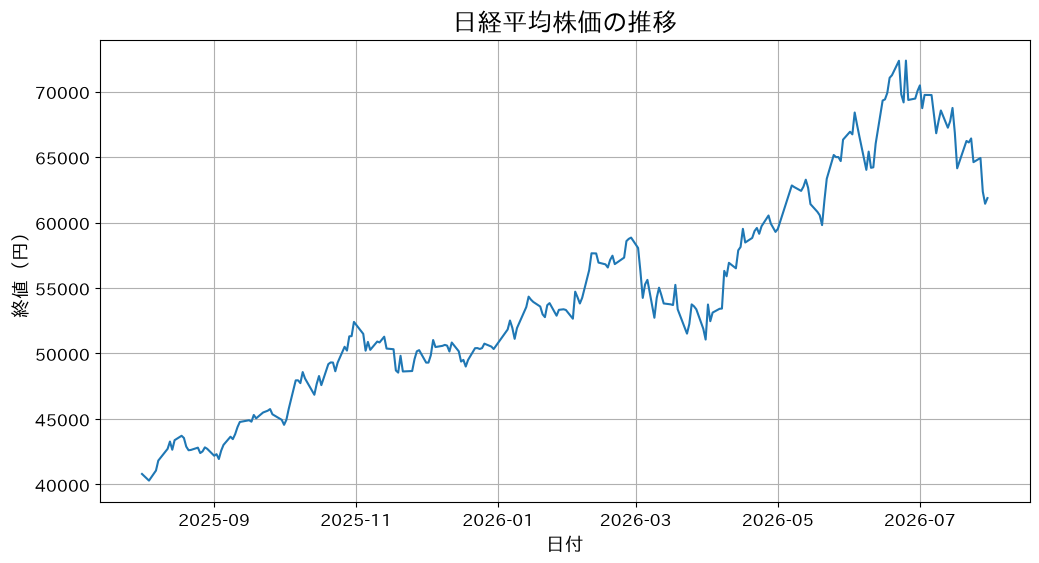

In [2]:
!pip install -q matplotlib_fontja

import matplotlib.pyplot as plt
import matplotlib_fontja

# 日本語表示を有効化
matplotlib_fontja.japanize()

# 日経平均株価の終値を折れ線グラフで表示
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["Close"])

# タイトルと軸ラベルを設定
plt.title("日経平均株価の推移", fontsize=18)
plt.xlabel("日付", fontsize=14)
plt.ylabel("終値（円）", fontsize=14)

# 目盛りの文字サイズを設定
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# グラフを表示
plt.grid(True)
plt.show()

# 移動平均の追加

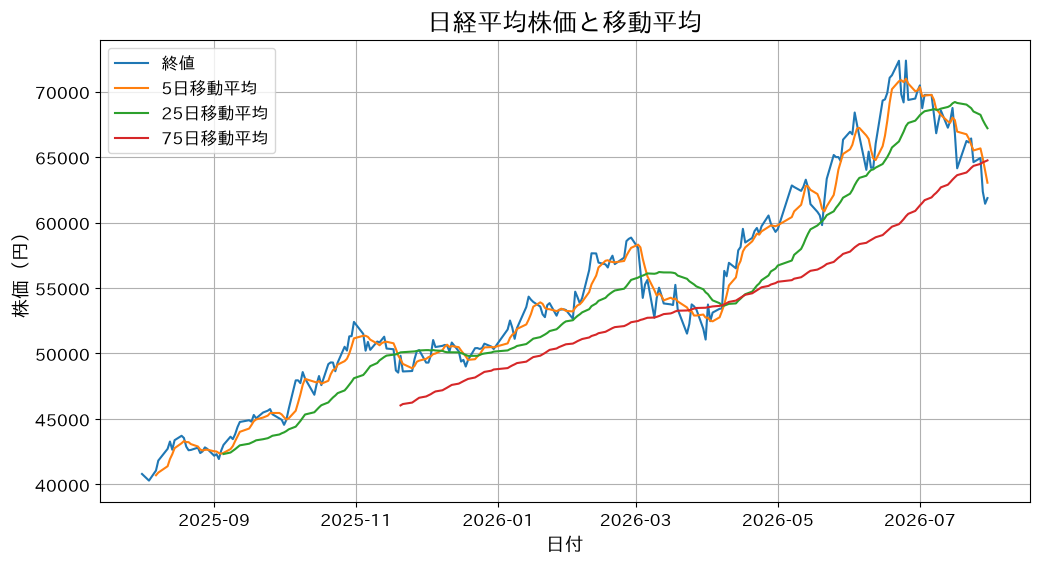

In [3]:
# 移動平均を計算
df["5日移動平均"] = df["Close"].rolling(window=5).mean()
df["25日移動平均"] = df["Close"].rolling(window=25).mean()
df["75日移動平均"] = df["Close"].rolling(window=75).mean()

# グラフを作成
plt.figure(figsize=(12, 6))

# 終値と移動平均を表示
plt.plot(df.index, df["Close"], label="終値")
plt.plot(df.index, df["5日移動平均"], label="5日移動平均")
plt.plot(df.index, df["25日移動平均"], label="25日移動平均")
plt.plot(df.index, df["75日移動平均"], label="75日移動平均")

# タイトルと軸ラベルを設定
plt.title("日経平均株価と移動平均", fontsize=18)
plt.xlabel("日付", fontsize=14)
plt.ylabel("株価（円）", fontsize=14)

# 目盛りの文字サイズを設定
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# 凡例を表示
plt.legend(fontsize=12)

# グラフを表示
plt.grid(True)
plt.show()

# 買い時と売り時の確認

【ゴールデンクロス：買いの参考】
5日移動平均線が25日移動平均線を下から上に越えたポイント
2025年12月08日
2025年12月24日
2026年04月08日

【デッドクロス：売りの参考】
5日移動平均線が25日移動平均線を上から下に越えたポイント
2025年11月19日
2025年12月18日
2026年03月06日
2026年07月09日


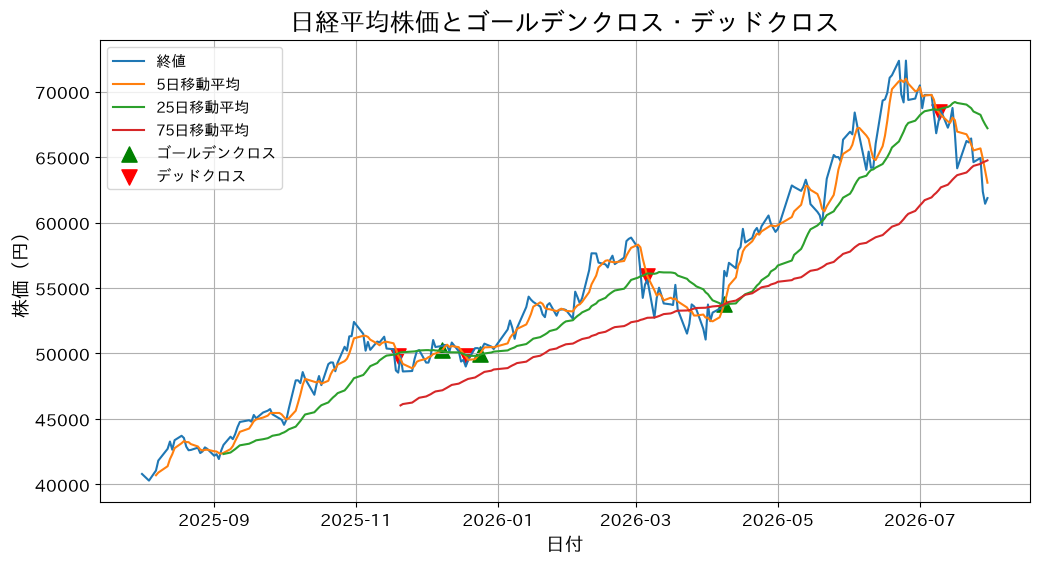

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib_fontja

# 日本語表示を有効化
matplotlib_fontja.japanize()

# -----------------------------
# 1. 終値を取得
# -----------------------------

close = df["Close"]

# yfinanceのデータが2次元の場合は1次元に変換
if isinstance(close, pd.DataFrame):
    close = close.iloc[:, 0]

# -----------------------------
# 2. 移動平均を計算
# -----------------------------

# 5日、25日、75日の移動平均
ma5 = close.rolling(window=5).mean()
ma25 = close.rolling(window=25).mean()
ma75 = close.rolling(window=75).mean()

# -----------------------------
# 3. ゴールデンクロスを検出
# -----------------------------

# 5日移動平均線が25日移動平均線を
# 下から上に越えたポイント
golden_cross = (
    (ma5 > ma25) &
    (ma5.shift(1) <= ma25.shift(1))
)

# -----------------------------
# 4. デッドクロスを検出
# -----------------------------

# 5日移動平均線が25日移動平均線を
# 上から下に越えたポイント
dead_cross = (
    (ma5 < ma25) &
    (ma5.shift(1) >= ma25.shift(1))
)

# -----------------------------
# 5. クロスが発生した日付を表示
# -----------------------------

print("【ゴールデンクロス：買いの参考】")
print("5日移動平均線が25日移動平均線を下から上に越えたポイント")

for date in df.index[golden_cross]:
    print(date.strftime("%Y年%m月%d日"))

print()

print("【デッドクロス：売りの参考】")
print("5日移動平均線が25日移動平均線を上から下に越えたポイント")

for date in df.index[dead_cross]:
    print(date.strftime("%Y年%m月%d日"))

# -----------------------------
# 6. グラフを作成
# -----------------------------

plt.figure(figsize=(12, 6))

# 終値と移動平均線
plt.plot(df.index, close, label="終値")
plt.plot(df.index, ma5, label="5日移動平均")
plt.plot(df.index, ma25, label="25日移動平均")
plt.plot(df.index, ma75, label="75日移動平均")

# ゴールデンクロスを表示
plt.scatter(
    df.index[golden_cross],
    ma5[golden_cross],
    marker="^",
    s=120,
    color="green",
    label="ゴールデンクロス"
)

# デッドクロスを表示
plt.scatter(
    df.index[dead_cross],
    ma5[dead_cross],
    marker="v",
    s=120,
    color="red",
    label="デッドクロス"
)

# -----------------------------
# 7. グラフの設定
# -----------------------------

plt.title(
    "日経平均株価とゴールデンクロス・デッドクロス",
    fontsize=18
)

plt.xlabel("日付", fontsize=14)
plt.ylabel("株価（円）", fontsize=14)

# 目盛りの文字サイズ
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# 凡例とグリッド
plt.legend(fontsize=11)
plt.grid(True)

# グラフを表示
plt.show()